In [1]:
# =============================================================================
# CELL 1 — IMPORTS
# =============================================================================

import yfinance as yf
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from statsmodels.tsa.stattools import adfuller, coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from scipy.optimize import minimize

In [2]:
# =============================================================================
# CELL 2 — DATA
# Train/test split enforced at data fetch level
# TRAIN: 2012-05-18 → 2022-12-31 (daily bars, MLE + cointegration only)
# TEST:  2023-01-01 → today      (daily bars, backtest only)
# No test data is ever touched during training steps
# =============================================================================

TRAIN_START = "2012-05-18"   # META IPO date
TRAIN_END   = "2022-12-31"
TEST_START  = "2023-01-01"
TEST_END    = datetime.datetime.today().strftime("%Y-%m-%d")

# --- Training data ---
meta_train_raw = yf.download("META", start=TRAIN_START, end=TRAIN_END,
                              auto_adjust=True, progress=False)["Close"].squeeze()
qqq_train_raw  = yf.download("QQQ",  start=TRAIN_START, end=TRAIN_END,
                              auto_adjust=True, progress=False)["Close"].squeeze()

train          = pd.concat([meta_train_raw, qqq_train_raw], axis=1).dropna()
train.columns  = ["META", "QQQ"]
meta_tr        = train["META"].values.astype(float)
qqq_tr         = train["QQQ"].values.astype(float)

# --- Test data ---
meta_test_raw  = yf.download("META", start=TEST_START, end=TEST_END,
                              auto_adjust=True, progress=False)["Close"].squeeze()
qqq_test_raw   = yf.download("QQQ",  start=TEST_START, end=TEST_END,
                              auto_adjust=True, progress=False)["Close"].squeeze()

test           = pd.concat([meta_test_raw, qqq_test_raw], axis=1).dropna()
test.columns   = ["META", "QQQ"]
meta_te        = test["META"].values.astype(float)
qqq_te         = test["QQQ"].values.astype(float)

print("=== Data Summary ===")
print(f"Train: {train.index[0].date()} → {train.index[-1].date()} "
      f"({len(train)} bars, {len(train)/252:.1f} years)")
print(f"Test:  {test.index[0].date()} → {test.index[-1].date()} "
      f"({len(test)} bars, {len(test)/252:.1f} years)")
print(f"\nTrain META: ${meta_tr[0]:.2f} → ${meta_tr[-1]:.2f}")
print(f"Train QQQ:  ${qqq_tr[0]:.2f} → ${qqq_tr[-1]:.2f}")
print(f"Test  META: ${meta_te[0]:.2f} → ${meta_te[-1]:.2f}")
print(f"Test  QQQ:  ${qqq_te[0]:.2f} → ${qqq_te[-1]:.2f}")

=== Data Summary ===
Train: 2012-05-18 → 2022-12-30 (2673 bars, 10.6 years)
Test:  2023-01-03 → 2026-04-28 (832 bars, 3.3 years)

Train META: $37.93 → $119.40
Train QQQ:  $53.86 → $261.23
Test  META: $123.77 → $671.34
Test  QQQ:  $259.47 → $657.55


In [3]:
# =============================================================================
# CELL 3 — KALMAN FILTER
# =============================================================================
# Run on TRAIN data for MLE calibration (Cell 4)
# Run on TEST data for backtest (Cell 6)
# Parameters flow one way only: train → test
# =============================================================================

def kalman_filter(meta, qqq, delta=1e-4, Ve=0.001):
    """
    Kalman Filter for dynamic hedge ratio estimation.
    State vector: [β₀, β₁] where META_t = β₀ + β₁·QQQ_t + ε_t
    """
    n  = len(meta)
    Vw = delta / (1 - delta) * np.eye(2)

    beta = np.zeros((n, 2))
    P    = np.zeros((n, 2, 2))
    e    = np.zeros(n)
    Q    = np.zeros(n)

    beta[0] = [0, 1]
    P[0]    = np.eye(2)

    for t in range(1, n):
        F         = np.array([1.0, qqq[t]])
        beta_pred = beta[t-1]
        P_pred    = P[t-1] + Vw

        e[t] = meta[t] - F @ beta_pred
        Q[t] = F @ P_pred @ F + Ve

        K       = (P_pred @ F) / Q[t]
        beta[t] = beta_pred + K * e[t]
        P[t]    = P_pred - np.outer(K, F) @ P_pred

    return beta, e, Q

# Run on training data — used for MLE calibration only
beta_tr, e_tr, Q_tr = kalman_filter(meta_tr, qqq_tr)

print("=== Kalman Filter — Training Data (default params) ===")
print(f"β₁ mean:  {beta_tr[:,1].mean():.4f}")
print(f"β₁ std:   {beta_tr[:,1].std():.4f}")
print(f"β₁ range: [{beta_tr[:,1].min():.4f}, {beta_tr[:,1].max():.4f}]")
print(f"\nSpread stats (train):")
print(pd.Series(e_tr).describe().round(4))

=== Kalman Filter — Training Data (default params) ===
β₁ mean:  0.8800
β₁ std:   0.2475
β₁ range: [0.2818, 1.2711]

Spread stats (train):
count    2673.0000
mean       -0.0616
std         3.0158
min       -71.4819
25%        -0.8848
50%        -0.0440
75%         0.8554
max        24.2736
dtype: float64


In [4]:
# =============================================================================
# CELL 4 — COINTEGRATION TESTING (TRAIN ONLY)
# =============================================================================
# All tests run on training data only
# Results inform methodology but do not touch test data
# =============================================================================

# 4A — ADF on individual train series
adf_meta_tr = adfuller(meta_tr, autolag="AIC")
adf_qqq_tr  = adfuller(qqq_tr,  autolag="AIC")

print("=== 4A — ADF: Individual Price Series (Train) ===")
print(f"META — p: {adf_meta_tr[1]:.4f}, "
      f"non-stationary: {adf_meta_tr[1] > 0.05}")
print(f"QQQ  — p: {adf_qqq_tr[1]:.4f},  "
      f"non-stationary: {adf_qqq_tr[1] > 0.05}")

# 4B — Engle-Granger
eg_stat, eg_pval, eg_crit = coint(meta_tr, qqq_tr)

print("\n=== 4B — Engle-Granger Cointegration Test (Train) ===")
print(f"Stat: {eg_stat:.4f}, p-value: {eg_pval:.4f}")
print(f"Critical values — 1%: {eg_crit[0]:.4f}, "
      f"5%: {eg_crit[1]:.4f}, 10%: {eg_crit[2]:.4f}")
print(f"Cointegrated at 5%: {eg_pval < 0.05}")

# 4C — Johansen
joh = coint_johansen(train[["META", "QQQ"]], det_order=0, k_ar_diff=1)

print("\n=== 4C — Johansen Cointegration Test (Train) ===")
print(f"r=0 — stat: {joh.lr1[0]:.4f}, "
      f"95% crit: {joh.cvt[0,1]:.4f}, "
      f"reject: {joh.lr1[0] > joh.cvt[0,1]}")
print(f"r=1 — stat: {joh.lr1[1]:.4f}, "
      f"95% crit: {joh.cvt[1,1]:.4f}, "
      f"reject: {joh.lr1[1] > joh.cvt[1,1]}")

# 4D — OLS spread half-life on training data
A        = np.vstack([np.ones(len(meta_tr)), qqq_tr]).T
coeffs   = np.linalg.lstsq(A, meta_tr, rcond=None)[0]
beta_ols = coeffs[1]

ols_spread = meta_tr - (coeffs[0] + beta_ols * qqq_tr)
ols_series = pd.Series(ols_spread, index=train.index)
adf_ols    = adfuller(ols_spread, autolag="AIC")

s_lag  = ols_series.shift(1).dropna()
s_diff = ols_series.diff().dropna()
phi    = np.polyfit(s_lag.values, s_diff.values, 1)[0]

print("\n=== 4D — OLS Spread + Half-Life (Train) ===")
print(f"ADF p-value:      {adf_ols[1]:.4f} — "
      f"stationary: {adf_ols[1] < 0.05}")
print(f"OLS hedge ratio:  {beta_ols:.4f} (fixed — train period mean)")

if -1 < phi < 0:
    hl = -np.log(2) / np.log(1 + phi)
    print(f"Half-life:        {hl:.1f} days")
    print(f"Rolling window:   {int(hl * 2)} days "
          f"(2 × half-life rule)")
else:
    hl = None
    print(f"φ = {phi:.4f} — no clean OU mean reversion")

# 4E — Kalman spread stationarity on training data
adf_kalman_tr = adfuller(e_tr[10:], autolag="AIC")

print("\n=== 4E — Kalman Spread Stationarity (Train) ===")
print(f"ADF stat:  {adf_kalman_tr[0]:.4f}")
print(f"P-value:   {adf_kalman_tr[1]:.4f} — "
      f"stationary: {adf_kalman_tr[1] < 0.05}")

# Summary
print("\n=== Cointegration Suite Summary ===")
print(f"{'Test':<35} {'Result':<15} {'Interpretation'}")
print("-" * 70)
print(f"{'ADF — META (train)':<35} "
      f"{'p='+str(round(adf_meta_tr[1],3)):<15} Non-stationary ✓")
print(f"{'ADF — QQQ (train)':<35} "
      f"{'p='+str(round(adf_qqq_tr[1],3)):<15} Non-stationary ✓")
print(f"{'Engle-Granger (train)':<35} "
      f"{'p='+str(round(eg_pval,3)):<15} "
      f"{'Cointegrated ✓' if eg_pval < 0.05 else 'Not cointegrated'}")
print(f"{'Johansen (train)':<35} "
      f"{'Reject r=0' if joh.lr1[0] > joh.cvt[0,1] else 'Fails 95%':<15} "
      f"{'Cointegrated ✓' if joh.lr1[0] > joh.cvt[0,1] else 'Not cointegrated'}")
print(f"{'ADF — OLS spread (train)':<35} "
      f"{'p='+str(round(adf_ols[1],3)):<15} "
      f"{'Stationary ✓' if adf_ols[1] < 0.05 else 'Non-stationary'}")
if hl:
    print(f"{'Half-life (train)':<35} "
          f"{str(round(hl,1))+' days':<15} "
          f"Rolling window → {int(hl*2)} days")
print(f"{'ADF — Kalman spread (train)':<35} "
      f"{'p='+str(round(adf_kalman_tr[1],4)):<15} "
      f"{'Stationary ✓✓' if adf_kalman_tr[1] < 0.05 else 'Non-stationary'}")

=== 4A — ADF: Individual Price Series (Train) ===
META — p: 0.4959, non-stationary: True
QQQ  — p: 0.8268,  non-stationary: True

=== 4B — Engle-Granger Cointegration Test (Train) ===
Stat: -1.1209, p-value: 0.8774
Critical values — 1%: -3.9005, 5%: -3.3384, 10%: -3.0460
Cointegrated at 5%: False

=== 4C — Johansen Cointegration Test (Train) ===
r=0 — stat: 12.2465, 95% crit: 15.4943, reject: False
r=1 — stat: 3.8627, 95% crit: 3.8415, reject: True

=== 4D — OLS Spread + Half-Life (Train) ===
ADF p-value:      0.7070 — stationary: False
OLS hedge ratio:  0.8320 (fixed — train period mean)
Half-life:        398.3 days
Rolling window:   796 days (2 × half-life rule)

=== 4E — Kalman Spread Stationarity (Train) ===
ADF stat:  -21.1253
P-value:   0.0000 — stationary: True

=== Cointegration Suite Summary ===
Test                                Result          Interpretation
----------------------------------------------------------------------
ADF — META (train)                  p=0.496   

In [5]:
# =============================================================================
# CELL 5 — MLE CALIBRATION (TRAIN ONLY)
# =============================================================================
# Optimise δ and Ve on training data only
# These parameters are then frozen and applied to test data
# Bounded optimisation to prevent degenerate solutions (Ve → 0)
# =============================================================================

def kalman_loglik(params, meta, qqq):
    """
    Negative log-likelihood of Kalman filter.
    params = [delta, Ve] in natural space with bounds.
    """
    delta = np.clip(params[0], 1e-8, 0.9999)
    Ve    = params[1]

    n  = len(meta)
    Vw = delta / (1 - delta) * np.eye(2)

    beta    = np.zeros((n, 2))
    P       = np.zeros((n, 2, 2))
    log_lik = 0.0

    beta[0] = [0, 1]
    P[0]    = np.eye(2)

    for t in range(1, n):
        F         = np.array([1.0, qqq[t]])
        beta_pred = beta[t-1]
        P_pred    = P[t-1] + Vw

        e_t = meta[t] - F @ beta_pred
        Q_t = F @ P_pred @ F + Ve

        if Q_t <= 0:
            continue

        log_lik += -0.5 * (np.log(Q_t) + e_t**2 / Q_t)

        K       = (P_pred @ F) / Q_t
        beta[t] = beta_pred + K * e_t
        P[t]    = P_pred - np.outer(K, F) @ P_pred

    return -log_lik

# Bounds — Ve minimum 0.01 prevents degenerate zero-noise solution
bounds = [(1e-6, 0.01), (0.01, 100.0)]
x0     = [1e-4, 0.1]

result = minimize(
    kalman_loglik,
    x0,
    args=(meta_tr, qqq_tr),
    method="L-BFGS-B",
    bounds=bounds,
    options={"maxiter": 10000, "ftol": 1e-12, "gtol": 1e-8}
)

delta_mle = result.x[0]
Ve_mle    = result.x[1]

print("=== MLE Calibration Results (Train: 2012-2023) ===")
print(f"Converged:  {result.success}")
print(f"Message:    {result.message}")
print(f"\n{'Parameter':<10} {'Value':<15} {'Bounds'}")
print("-" * 35)
print(f"{'delta':<10} {delta_mle:.4e}     [1e-6, 0.01]")
print(f"{'Ve':<10} {Ve_mle:.4e}     [0.01, 100]")

# Verify on training spread
beta_tr_mle, e_tr_mle, _ = kalman_filter(
    meta_tr, qqq_tr, delta=delta_mle, Ve=Ve_mle)

adf_tr_mle = adfuller(e_tr_mle[10:], autolag="AIC")
print(f"\n=== Train Spread Stationarity (MLE params) ===")
print(f"ADF p-value: {adf_tr_mle[1]:.4f} — "
      f"stationary: {adf_tr_mle[1] < 0.05}")
print(f"β₁ mean: {beta_tr_mle[:,1].mean():.4f}")
print(f"β₁ std:  {beta_tr_mle[:,1].std():.4f}")

# =============================================================================
# PARAMETERS ARE NOW FROZEN
# delta_mle and Ve_mle will not change from this point forward
# All subsequent cells use these values on test data only
# =============================================================================
print(f"\n{'='*40}")
print(f"FROZEN PARAMETERS FOR TEST SET:")
print(f"  delta = {delta_mle:.4e}")
print(f"  Ve    = {Ve_mle:.4e}")
print(f"{'='*40}")

=== MLE Calibration Results (Train: 2012-2023) ===
Converged:  True
Message:    CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

Parameter  Value           Bounds
-----------------------------------
delta      2.1246e-04     [1e-6, 0.01]
Ve         1.0000e-02     [0.01, 100]

=== Train Spread Stationarity (MLE params) ===
ADF p-value: 0.0000 — stationary: True
β₁ mean: 0.8770
β₁ std:  0.2449

FROZEN PARAMETERS FOR TEST SET:
  delta = 2.1246e-04
  Ve    = 1.0000e-02


In [6]:
# =============================================================================
# CELL 6 — TEST SET: KALMAN FILTER + VOL-SCALED Z-SCORE
# =============================================================================
# Frozen parameters from Cell 5 applied to test data only
# No parameter touching from this point forward
#
# VOL-SCALED ENTRY THRESHOLD:
# threshold_t = k × rolling_std(zscore, vol_window)
# When vol is high → threshold rises → harder to enter → fewer trades
# When vol is low  → threshold falls → easier to enter → more trades
# =============================================================================

# -----------------------------------------------------------------------------
# 6A — KALMAN FILTER ON TEST DATA
# -----------------------------------------------------------------------------
beta_te, e_te, Q_te = kalman_filter(
    meta_te, qqq_te,
    delta=delta_mle,   # frozen from Cell 5
    Ve=Ve_mle          # frozen from Cell 5
)

# Verify test spread stationarity — should hold out of sample
adf_te = adfuller(e_te[10:], autolag="AIC")
print("=== 6A — Test Spread Stationarity ===")
print(f"ADF p-value: {adf_te[1]:.4f} — "
      f"stationary: {adf_te[1] < 0.05}")
print(f"β₁ mean:  {beta_te[:,1].mean():.4f}")
print(f"β₁ std:   {beta_te[:,1].std():.4f}")
print(f"β₁ range: [{beta_te[:,1].min():.4f}, {beta_te[:,1].max():.4f}]")

# -----------------------------------------------------------------------------
# 6B — MAD Z-SCORE ON TEST SPREAD
# Window = 60 days (3 months) — practical choice given 398-day half-life
# means OLS-based window selection is not applicable here
# -----------------------------------------------------------------------------
def rolling_mad_zscore(spread, window):
    """
    Robust z-score using median and MAD.
    Scaled by 1.4826 to match std under Gaussian assumptions.
    """
    median = spread.rolling(window).median()
    mad    = (spread - median).abs().rolling(window).median() * 1.4826
    return (spread - median) / mad

spread_te = pd.Series(e_te, index=test.index)
window    = 60   # 3 months of daily bars

zscore    = rolling_mad_zscore(spread_te, window)
zscore    = zscore.clip(-4, 4)

print("\n=== 6B — Z-Score Stats (Test) ===")
print(zscore.describe().round(4))
print(f"\nBars beyond ±1: {(zscore.abs() > 1).sum()} / "
      f"{zscore.notna().sum()}")
print(f"Bars beyond ±2: {(zscore.abs() > 2).sum()} / "
      f"{zscore.notna().sum()}")

# -----------------------------------------------------------------------------
# 6C — VOL-SCALED ENTRY THRESHOLD
# threshold_t = k × rolling_std(zscore, vol_window)
# vol_window  = 20 days (1 month) — responsive but not noisy
# k           = 1.5 — tighter than fixed ±2, more selective
# -----------------------------------------------------------------------------
k          = 1.5
vol_window = 20

zscore_vol    = zscore.rolling(vol_window).std()
threshold     = k * zscore_vol

# Clip threshold to reasonable range
# Minimum 0.5 — never enter on tiny moves
# Maximum 2.5 — never require extreme moves to enter
threshold     = threshold.clip(0.5, 2.5)

print("\n=== 6C — Vol-Scaled Threshold Stats ===")
print(threshold.describe().round(4))
print(f"\nMean threshold:   {threshold.mean():.4f}")
print(f"Min threshold:    {threshold.min():.4f}")
print(f"Max threshold:    {threshold.max():.4f}")
print(f"\nFor reference — fixed threshold would be: 2.0")
print(f"Vol-scaled mean:  {threshold.mean():.4f} "
      f"({'tighter' if threshold.mean() < 2.0 else 'looser'} than fixed)")

=== 6A — Test Spread Stationarity ===
ADF p-value: 0.0000 — stationary: True
β₁ mean:  1.0279
β₁ std:   0.2121
β₁ range: [0.4840, 1.3788]

=== 6B — Z-Score Stats (Test) ===
count    714.0000
mean       0.0386
std        1.2072
min       -4.0000
25%       -0.6820
50%        0.0031
75%        0.7182
max        4.0000
dtype: float64

Bars beyond ±1: 240 / 714
Bars beyond ±2: 71 / 714

=== 6C — Vol-Scaled Threshold Stats ===
count    695.0000
mean       1.7412
std        0.4291
min        0.9361
25%        1.4008
50%        1.6412
75%        2.1203
max        2.5000
dtype: float64

Mean threshold:   1.7412
Min threshold:    0.9361
Max threshold:    2.5000

For reference — fixed threshold would be: 2.0
Vol-scaled mean:  1.7412 (tighter than fixed)


In [11]:
# =============================================================================
# CELL 7 — SIGNAL GENERATION & BACKTEST (CORRECTED SIGN)
# =============================================================================

# Z-score and threshold lags
zscore_lag    = zscore.shift(1)
threshold_lag = threshold.shift(1)
stop_loss     = 3.5

signals  = pd.Series(0, index=test.index)
position = 0

for t in range(1, len(test)):
    z   = zscore_lag.iloc[t]
    thr = threshold_lag.iloc[t]

    if np.isnan(z) or np.isnan(thr):
        signals.iloc[t] = 0
        position        = 0
        continue

    if position == 0:
        if z < -thr:         position = 1
        elif z > thr:        position = -1
    elif position == 1:
        if z >= 0:           position = 0
        elif z < -stop_loss: position = 0
    elif position == -1:
        if z <= 0:           position = 0
        elif z > stop_loss:  position = 0

    signals.iloc[t] = position

# --- Returns ---
meta_ret     = test["META"].pct_change()
qqq_ret      = test["QQQ"].pct_change()
beta_series  = pd.Series(beta_te[:, 1], index=test.index)
spread_ret   = (meta_ret - beta_series * qqq_ret)   # corrected sign
strategy_ret = (signals.shift(1) * spread_ret).dropna()

# --- Trade isolation ---
sig_lagged = signals.shift(1).dropna()

current_dir, current_entry, trade_list = 0, None, []
for t in range(len(sig_lagged)):
    s = sig_lagged.iloc[t]
    if current_dir == 0 and s != 0:
        current_entry = t
        current_dir   = int(s)
    elif current_dir != 0 and s == 0:
        trade_list.append((current_entry, t))
        current_entry, current_dir = None, 0

# --- PnL per trade ---
pnls    = []
lengths = []
for eb, xb in trade_list:
    if xb > eb:
        pnls.append(strategy_ret.iloc[eb:xb].sum())
        lengths.append(xb - eb)

pnls    = np.array(pnls)
lengths = np.array(lengths)

print("=== 7A — Signal Stats ===")
print(f"Bars long:       {(signals ==  1).sum()}")
print(f"Bars short:      {(signals == -1).sum()}")
print(f"Bars flat:       {(signals ==  0).sum()}")
print(f"Complete trades: {len(trade_list)}")
print(f"Mean PnL/trade:  {pnls.mean():.4%}")
print(f"Mean hold:       {lengths.mean():.1f} days")
print(f"Win rate:        {(pnls > 0).mean():.1%}")

# --- Performance metrics ---
ann_factor = 252

def compute_metrics(ret, cost_bps, trade_list, label):
    cost    = cost_bps / 10000
    costs_s = pd.Series(0.0, index=ret.index)
    for eb, _ in trade_list:
        if eb < len(costs_s):
            costs_s.iloc[eb] = cost
    net    = ret - costs_s
    equity = (1 + net).cumprod()
    sharpe = (net.mean() / net.std()) * np.sqrt(ann_factor)
    total  = equity.iloc[-1] - 1
    max_dd = ((equity - equity.cummax()) / equity.cummax()).min()
    win    = (net[net != 0] > 0).mean()
    print(f"\n--- {label} ---")
    print(f"Total Return:  {total:.2%}")
    print(f"Sharpe Ratio:  {sharpe:.2f}")
    print(f"Max Drawdown:  {max_dd:.2%}")
    print(f"Win Rate:      {win:.2%}")
    return net, equity, sharpe

print("\n=== 7B — Performance Metrics ===")
net_gross, eq_gross, sh_gross = compute_metrics(
    strategy_ret, 0, trade_list, "Gross (0 bps)")
net_real,  eq_real,  sh_real  = compute_metrics(
    strategy_ret, 3, trade_list, "Net — realistic (3 bps)")
net_cons,  eq_cons,  sh_cons  = compute_metrics(
    strategy_ret, 6, trade_list, "Net — conservative (6 bps)")

print(f"\n=== 7C — Cost Sensitivity ===")
print(f"{'Cost (bps)':<12} {'Sharpe':<10} {'Return':<10} {'Max DD'}")
print("-" * 42)
for bps in [0, 1, 2, 3, 4, 5, 6, 8, 10]:
    c      = bps / 10000
    cs     = pd.Series(0.0, index=strategy_ret.index)
    for eb, _ in trade_list:
        if eb < len(cs):
            cs.iloc[eb] = c
    net    = strategy_ret - cs
    eq     = (1 + net).cumprod()
    sh     = (net.mean() / net.std()) * np.sqrt(ann_factor)
    ret    = eq.iloc[-1] - 1
    dd     = ((eq - eq.cummax()) / eq.cummax()).min()
    print(f"{bps:<12} {sh:<10.2f} {ret:<10.2%} {dd:.2%}")

print(f"\n=== 7D — Trade Diagnostics ===")
print(f"Total cost drag (3 bps): {0.0003 * len(trade_list):.4%}")
print(f"Breakeven cost:          "
      f"~{pnls.mean() / 1 * 10000:.1f} bps per trade")

=== 7A — Signal Stats ===
Bars long:       74
Bars short:      74
Bars flat:       684
Complete trades: 71
Mean PnL/trade:  0.1869%
Mean hold:       2.1 days
Win rate:        50.7%

=== 7B — Performance Metrics ===

--- Gross (0 bps) ---
Total Return:  11.89%
Sharpe Ratio:  0.36
Max Drawdown:  -16.20%
Win Rate:      50.68%

--- Net — realistic (3 bps) ---
Total Return:  9.53%
Sharpe Ratio:  0.30
Max Drawdown:  -16.83%
Win Rate:      50.00%

--- Net — conservative (6 bps) ---
Total Return:  7.21%
Sharpe Ratio:  0.24
Max Drawdown:  -17.45%
Win Rate:      48.65%

=== 7C — Cost Sensitivity ===
Cost (bps)   Sharpe     Return     Max DD
------------------------------------------
0            0.36       11.89%     -16.20%
1            0.34       11.09%     -16.41%
2            0.32       10.31%     -16.62%
3            0.30       9.53%      -16.83%
4            0.28       8.75%      -17.04%
5            0.26       7.98%      -17.24%
6            0.24       7.21%      -17.45%
8            0.20

In [12]:
# =============================================================================
# CELL 8 — BOOTSTRAPPED SHARPE CONFIDENCE INTERVAL
# =============================================================================

ret_values  = net_real.dropna().values
n_obs       = len(ret_values)
n_bootstrap = 10000
sharpe_dist = np.zeros(n_bootstrap)

np.random.seed(42)
for i in range(n_bootstrap):
    sample         = np.random.choice(ret_values, size=n_obs, replace=True)
    sharpe_dist[i] = (sample.mean() / sample.std()) * np.sqrt(ann_factor)

ci_low  = np.percentile(sharpe_dist, 2.5)
ci_high = np.percentile(sharpe_dist, 97.5)
prob_positive = (sharpe_dist > 0).mean()

print("=== Bootstrapped Sharpe Ratio (10,000 samples) ===")
print(f"Point estimate:              {sh_real:.2f}")
print(f"95% CI:                      [{ci_low:.2f}, {ci_high:.2f}]")
print(f"Positive Sharpe probability: {prob_positive:.1%}")
print(f"\nInterpretation:")
if ci_low > 0:
    print(f"  Lower CI bound positive — strategy edge is statistically credible")
elif prob_positive > 0.75:
    print(f"  Lower CI crosses zero but {prob_positive:.1%} of samples positive")
    print(f"  Edge exists but requires longer sample to confirm statistically")
else:
    print(f"  Wide CI — insufficient sample to confirm edge statistically")
    print(f"  Positive point estimate but cannot rule out luck")

=== Bootstrapped Sharpe Ratio (10,000 samples) ===
Point estimate:              0.30
95% CI:                      [-0.87, 1.24]
Positive Sharpe probability: 69.8%

Interpretation:
  Wide CI — insufficient sample to confirm edge statistically
  Positive point estimate but cannot rule out luck


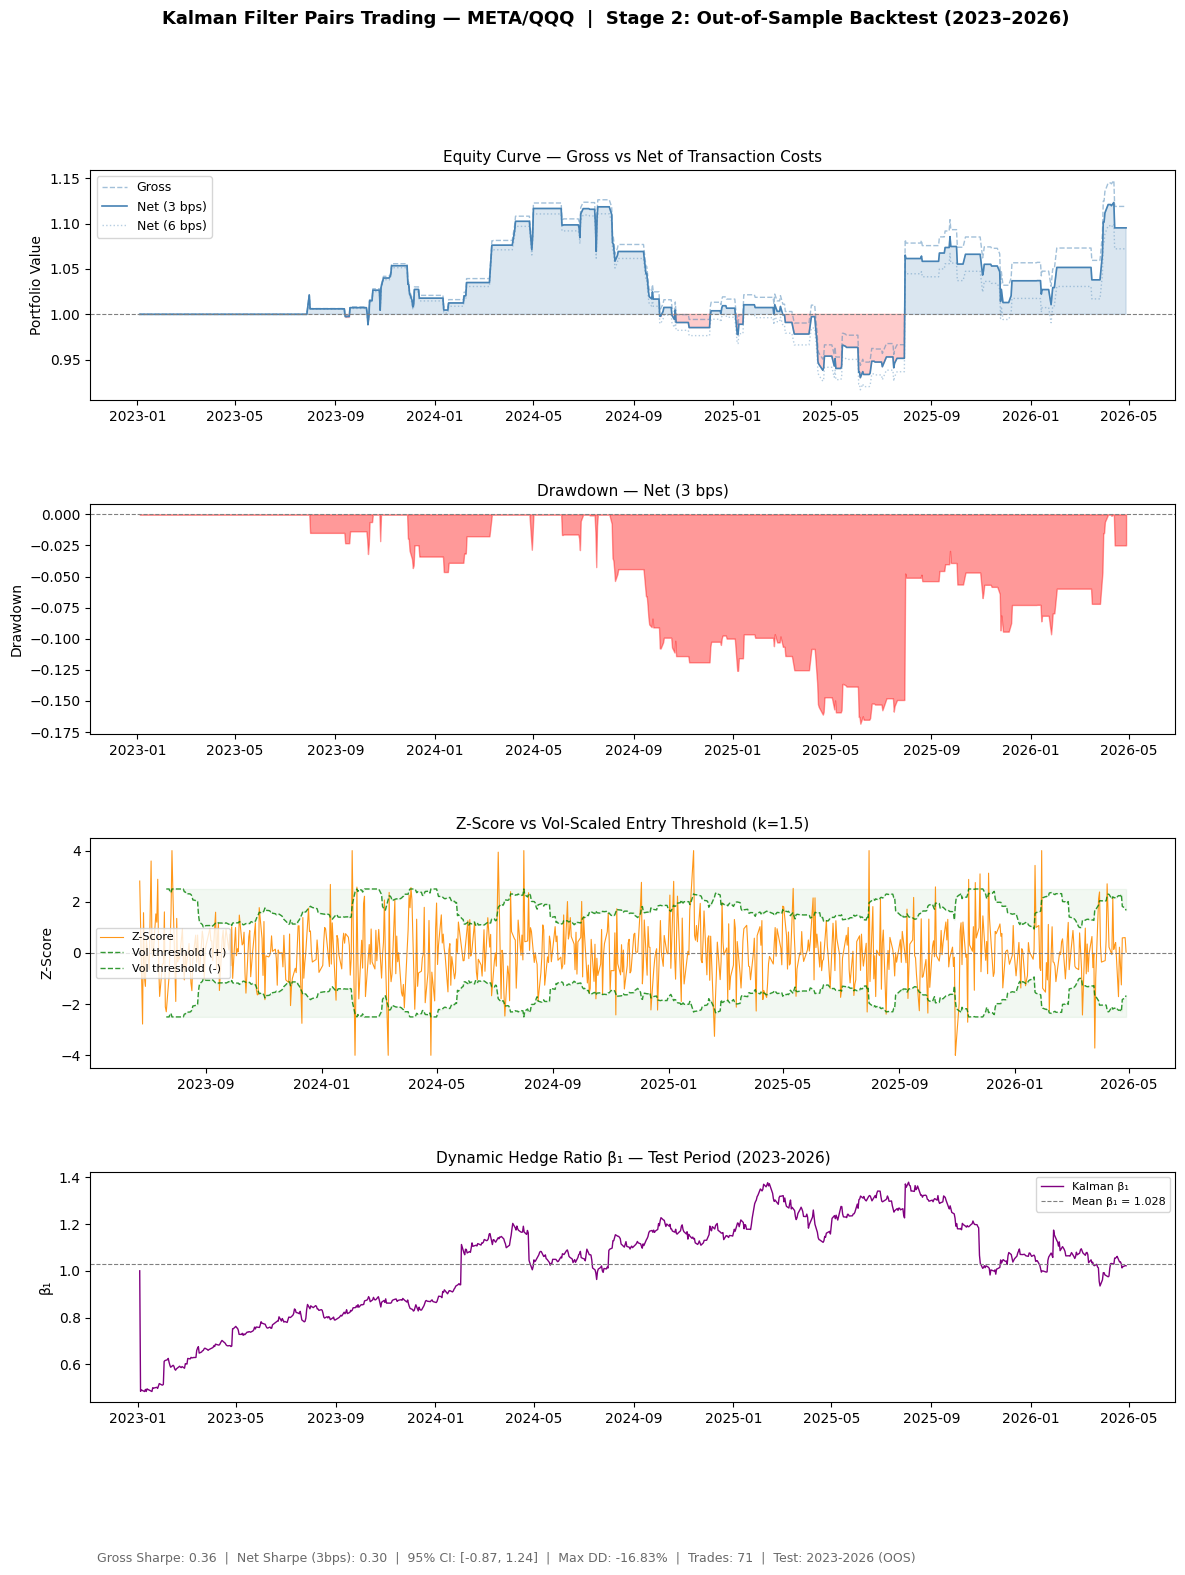

Saved — kalman_pairs_stage2_oos.png


In [13]:
# =============================================================================
# CELL 9 — VISUALISATION & TEARSHEET
# =============================================================================

fig = plt.figure(figsize=(14, 16))
gs  = gridspec.GridSpec(4, 1, hspace=0.45)

# --- Panel 1: Equity Curve ---
ax1 = fig.add_subplot(gs[0])
ax1.plot(eq_gross.index, eq_gross.values,
         color="steelblue", linewidth=1.0,
         linestyle="--", alpha=0.5, label="Gross")
ax1.plot(eq_real.index, eq_real.values,
         color="steelblue", linewidth=1.2, label="Net (3 bps)")
ax1.plot(eq_cons.index, eq_cons.values,
         color="steelblue", linewidth=1.0,
         linestyle=":", alpha=0.4, label="Net (6 bps)")
ax1.axhline(1, color="grey", linestyle="--", linewidth=0.8)
ax1.fill_between(eq_real.index, eq_real.values, 1,
                 where=eq_real.values >= 1,
                 alpha=0.2, color="steelblue")
ax1.fill_between(eq_real.index, eq_real.values, 1,
                 where=eq_real.values < 1,
                 alpha=0.2, color="red")
ax1.set_title("Equity Curve — Gross vs Net of Transaction Costs",
              fontsize=11)
ax1.set_ylabel("Portfolio Value")
ax1.legend(fontsize=9)

# --- Panel 2: Drawdown ---
ax2 = fig.add_subplot(gs[1])
drawdown = (eq_real - eq_real.cummax()) / eq_real.cummax()
ax2.fill_between(drawdown.index, drawdown.values, 0,
                 color="red", alpha=0.4)
ax2.axhline(0, color="grey", linestyle="--", linewidth=0.8)
ax2.set_title("Drawdown — Net (3 bps)", fontsize=11)
ax2.set_ylabel("Drawdown")

# --- Panel 3: Z-Score with vol-scaled threshold ---
ax3 = fig.add_subplot(gs[2])
ax3.plot(zscore.index, zscore.values,
         color="darkorange", linewidth=0.8,
         alpha=0.9, label="Z-Score")
ax3.plot(threshold.index, threshold.values,
         color="green", linewidth=1.0,
         linestyle="--", alpha=0.8, label="Vol threshold (+)")
ax3.plot(threshold.index, -threshold.values,
         color="green", linewidth=1.0,
         linestyle="--", alpha=0.8, label="Vol threshold (-)")
ax3.axhline(0, color="grey", linestyle="--", linewidth=0.8)
ax3.fill_between(threshold.index,
                 threshold.values, 2.5,
                 alpha=0.05, color="green")
ax3.fill_between(threshold.index,
                 -threshold.values, -2.5,
                 alpha=0.05, color="green")
ax3.set_title("Z-Score vs Vol-Scaled Entry Threshold (k=1.5)", fontsize=11)
ax3.set_ylabel("Z-Score")
ax3.legend(fontsize=8)
ax3.set_ylim(-4.5, 4.5)

# --- Panel 4: Dynamic Hedge Ratio (test period) ---
ax4 = fig.add_subplot(gs[3])
ax4.plot(test.index, beta_te[:, 1],
         color="purple", linewidth=1.0, label="Kalman β₁")
ax4.axhline(beta_te[:, 1].mean(), color="grey",
            linestyle="--", linewidth=0.8,
            label=f"Mean β₁ = {beta_te[:,1].mean():.3f}")
ax4.set_title("Dynamic Hedge Ratio β₁ — Test Period (2023-2026)",
              fontsize=11)
ax4.set_ylabel("β₁")
ax4.legend(fontsize=8)

# --- Footer ---
fig.text(
    0.13, 0.01,
    f"Gross Sharpe: {sh_gross:.2f}  |  "
    f"Net Sharpe (3bps): {sh_real:.2f}  |  "
    f"95% CI: [{ci_low:.2f}, {ci_high:.2f}]  |  "
    f"Max DD: {drawdown.min():.2%}  |  "
    f"Trades: {len(trade_list)}  |  "
    f"Test: 2023-2026 (OOS)",
    fontsize=9, color="dimgrey"
)

plt.suptitle(
    "Kalman Filter Pairs Trading — META/QQQ  |  "
    "Stage 2: Out-of-Sample Backtest (2023–2026)",
    fontsize=13, fontweight="bold"
)
plt.savefig("kalman_pairs_stage2_oos.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved — kalman_pairs_stage2_oos.png")